### 【[周末影音解盤](https://www.facebook.com/kevinyang20180801/videos/1228553032028876)】  
本周是2025年第一周開市表現偏弱，而且道瓊指數與標普500指數出現中期空方訊號，周五夜盤期指大漲，明天台股是否有機會跟進補漲？另外，台幣已經貶破長期支撐，下周要趕快站回哪個價位才是安全的？   
完整教學內容，詳見影音解盤~  
https://fb.watch/wVUArpu28S/  

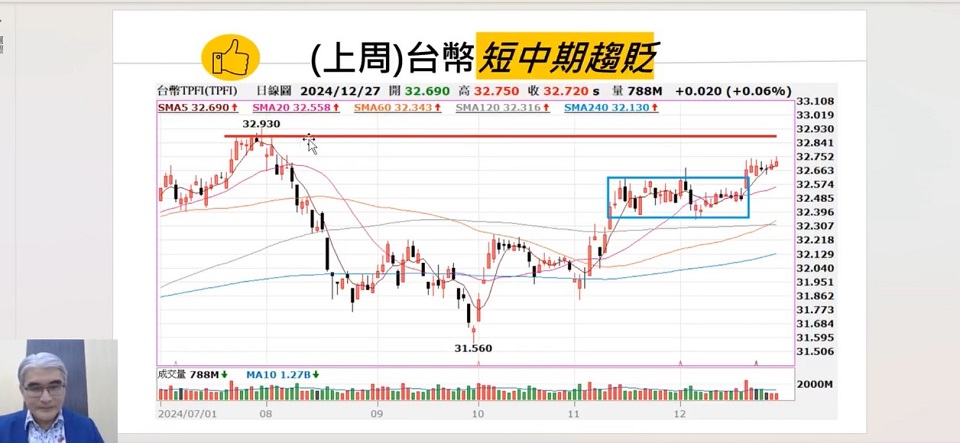  
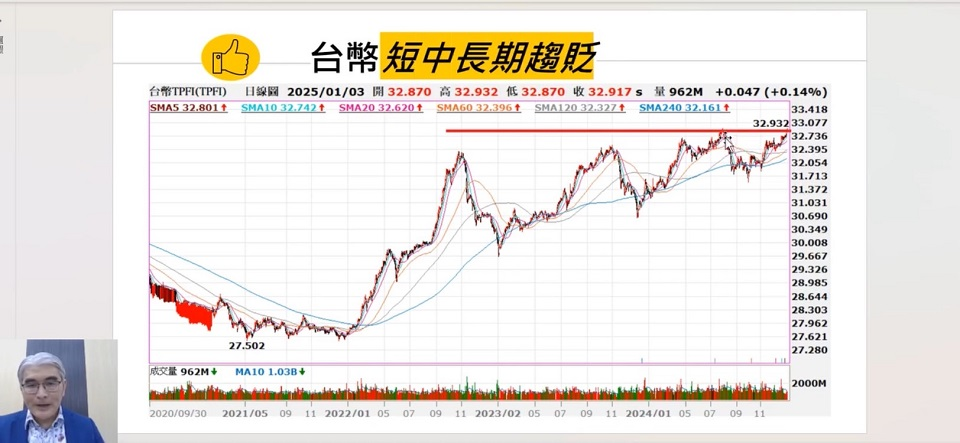  
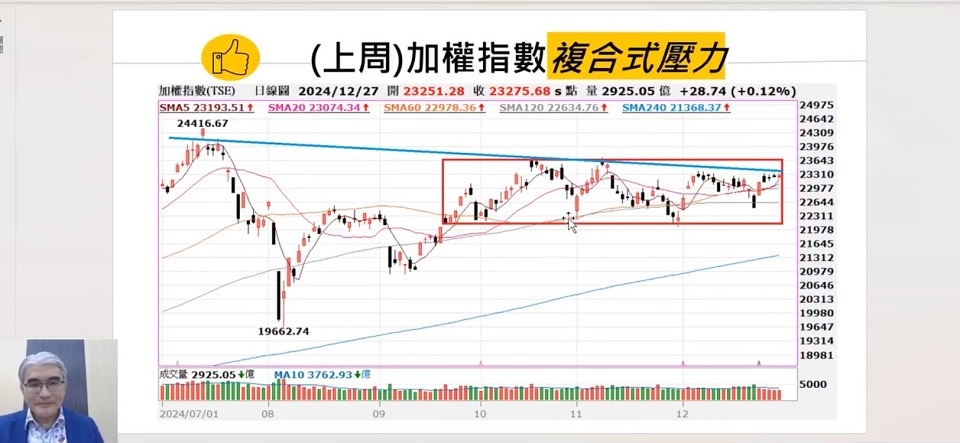  
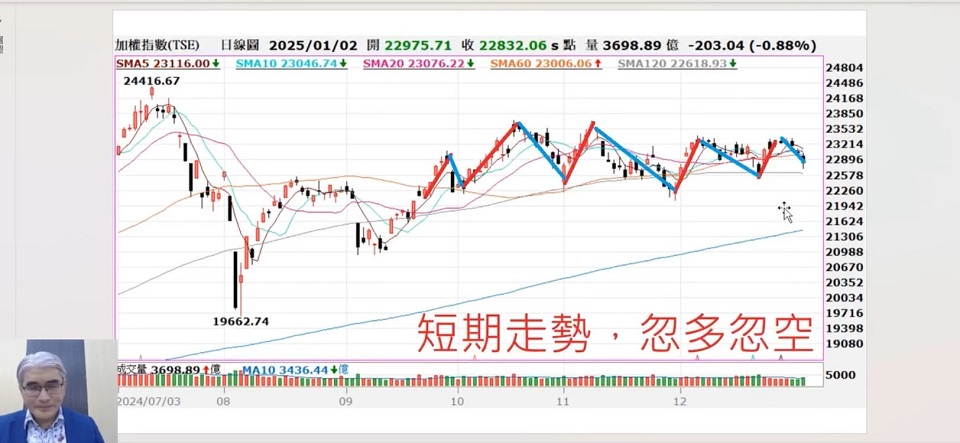  
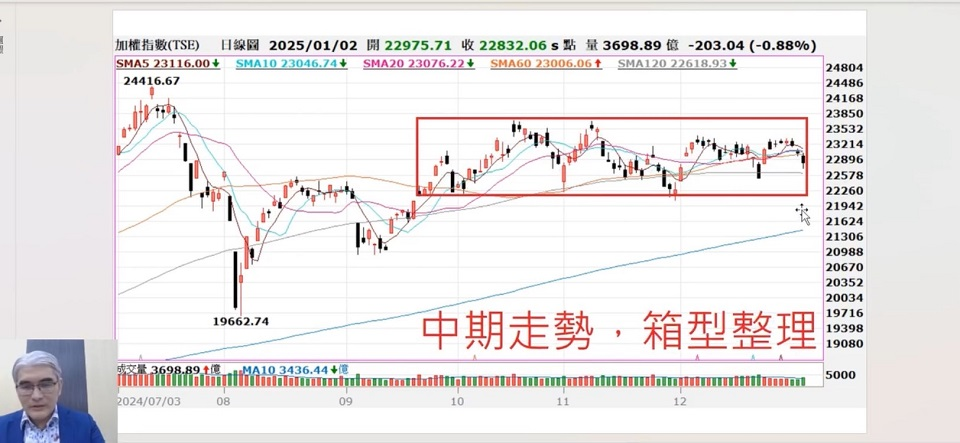  
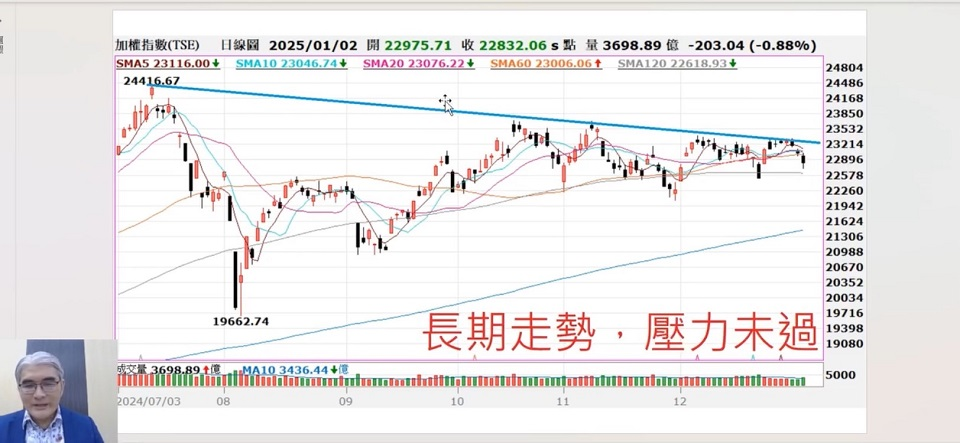  
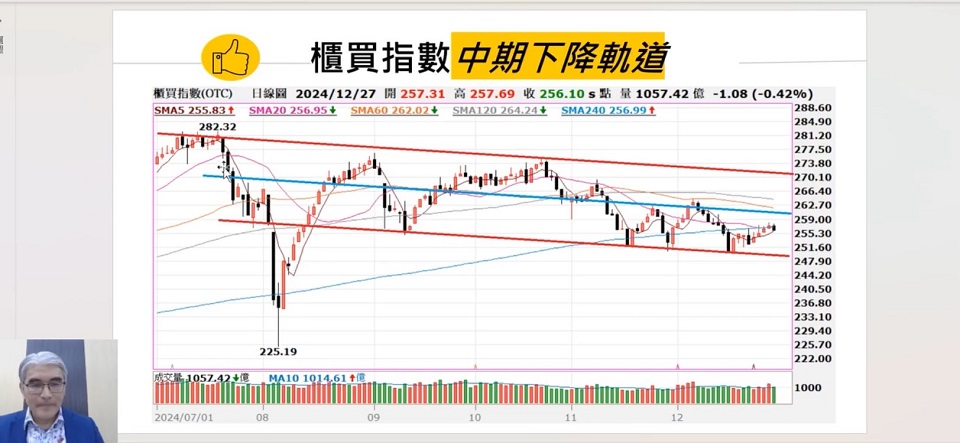  
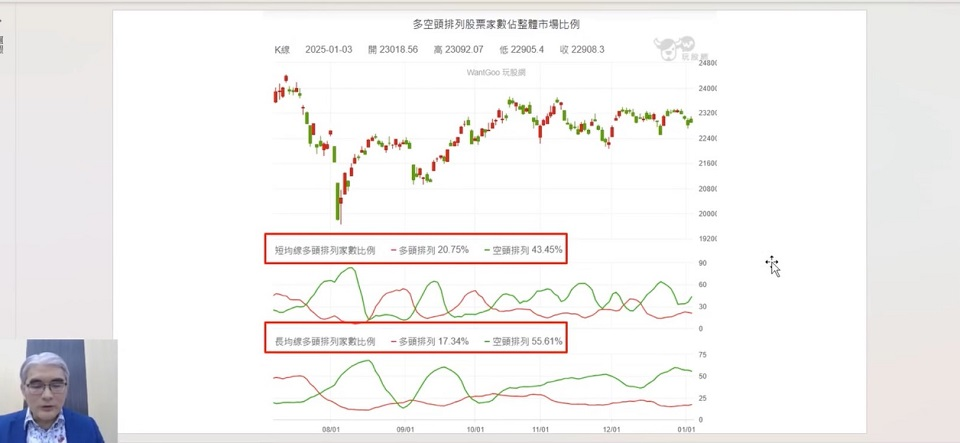  
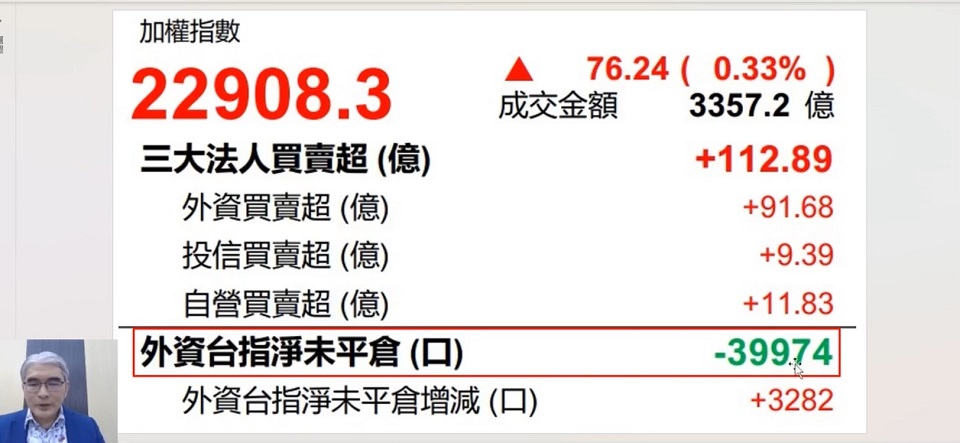  
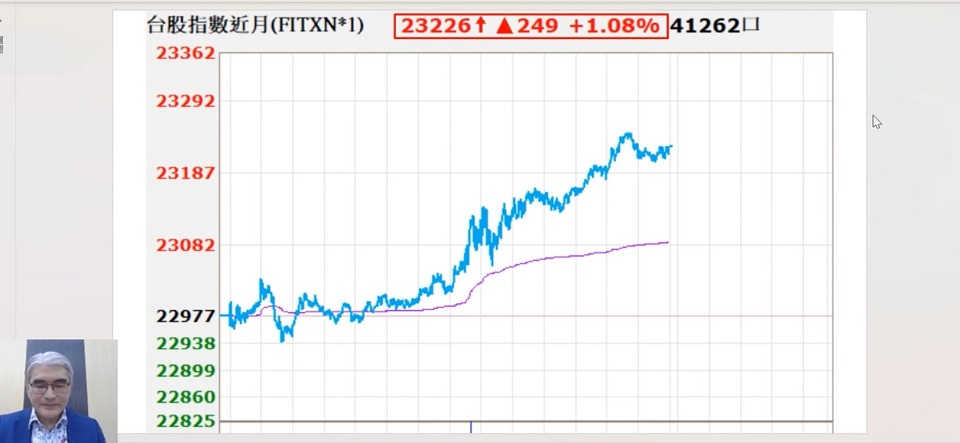  
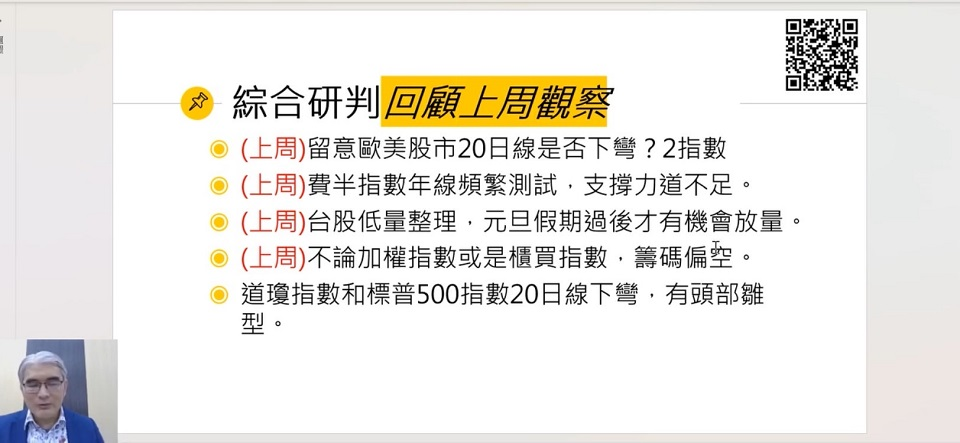  
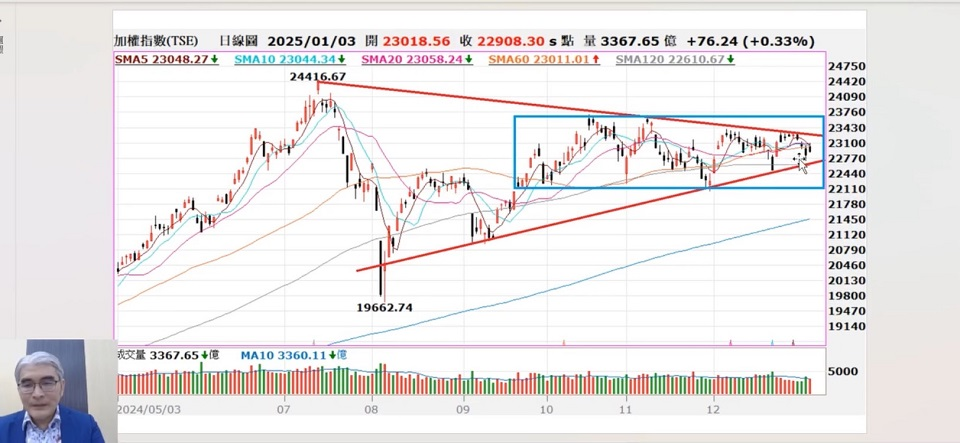  
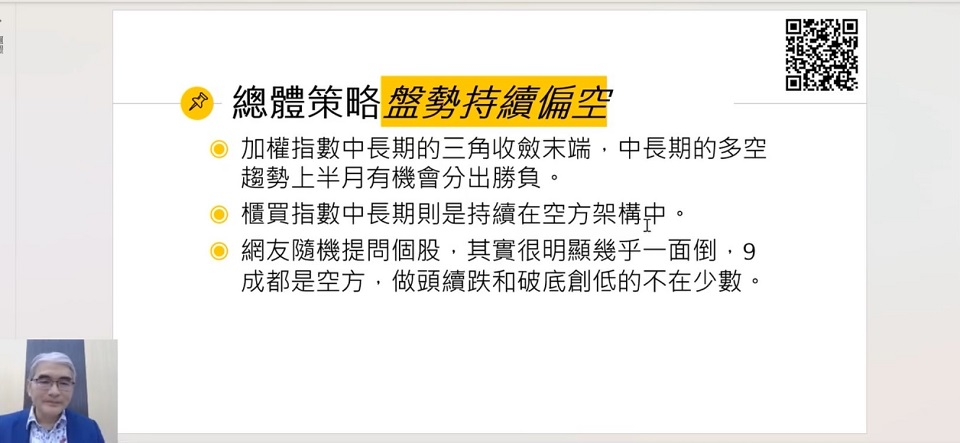  
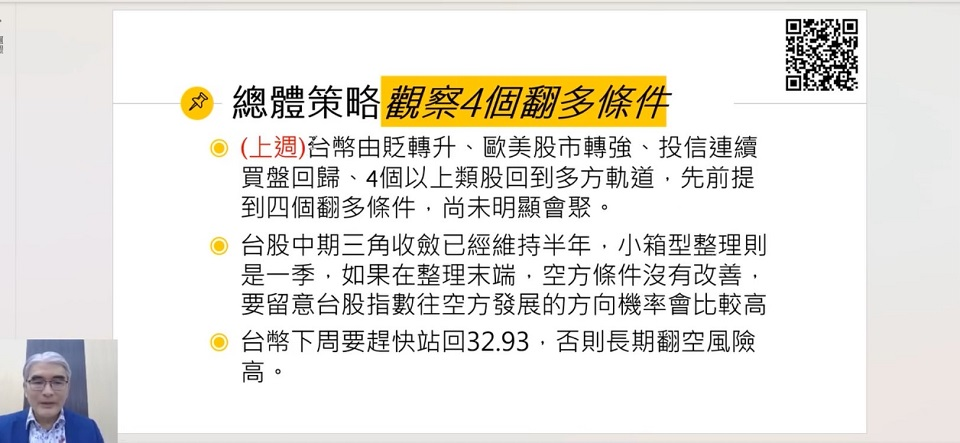  
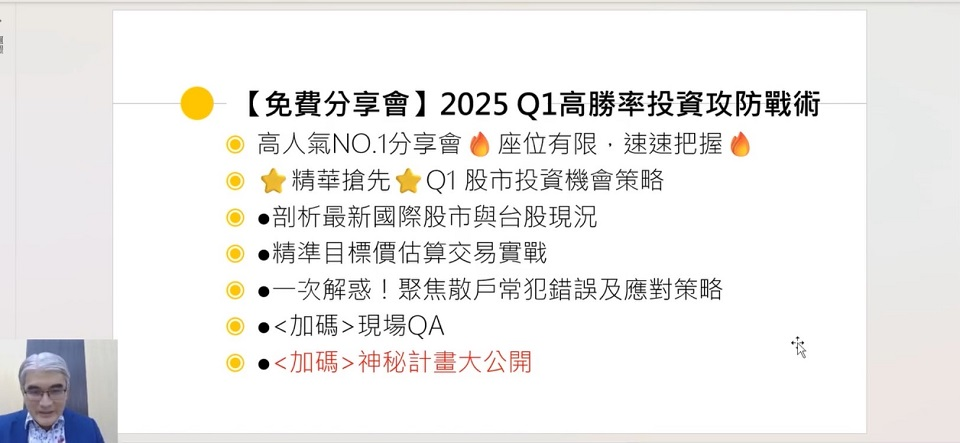  

### [K線捕手](https://www.facebook.com/kevinyang20180801)  
早上有事外出，中午前後才有空，所以比較沒有訊息，行情觀點可以再參考一下昨天的影音解盤。  

### 本日進度  
* 調整轉折點偵測程序以進行驗證。  

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

##### 偵測轉折點函式 #####
# prices    : 價格 (DataFrame)
# mode      : 模式 (str) ： 有'close'、'high_low'與'open_close'三種，預設為'close'
# interval  : 峰到谷或谷到峰之最小間隔 (int) → TODO ： 這邊的設定仍有待檢討
# smoothing : 平滑化參數 （當模式為'close'時有效） (int)
def DetectTurningPoints(prices, mode = 'close', interval = 1, smoothing = 1) :
    # 價格資料確認與處理
    if prices is None and type(prices) is not DataFrame:
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None    
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 模式確認與處理
    prices_date  = np.array(in_prices['Date'])
    prices_close = np.array(in_prices['Close'])
    if mode == 'close' :
        if smoothing > 1 :
            # 若為平滑化的收盤價,使用向前與向後傳播非空值的方法填充空(NaN)值;並將窗口標籤設置為窗口索引的中心，以正確反映趨勢
            prices_smooth_close = np.array(in_prices['Close'].rolling(window=smoothing,center=True).mean().fillna(method='bfill').fillna(method='ffill'))
            prices_high = prices_smooth_close
            prices_low  = prices_smooth_close
            # 模式改為'smooth_close'
            mode = 'smooth_close'
        else:
            prices_high = prices_close
            prices_low  = prices_close
    elif mode == 'high_low' :
        prices_high = np.array(in_prices['High'])
        prices_low  = np.array(in_prices['Low'])
    elif mode == 'open_close' :
        open_prices  = np.array(in_prices['Open'])
        close_prices = prices_close
        if len(open_prices) != len(close_prices) :
            return None
        prices_high_list = []
        prices_low_list  = []
        for idx in range(0,len(open_prices)) :
            if open_prices[idx] >= close_prices[idx] :
                prices_high_list.append(open_prices[idx])
                prices_low_list.append(close_prices[idx])
            else :
                prices_high_list.append(close_prices[idx])
                prices_low_list.append(open_prices[idx])
        prices_high = np.array(prices_high_list)
        prices_low  = np.array(prices_low_list)
    else :
        return None
    if len(prices_high) != len(prices_low) or len(prices_high) != len(prices_close) or len(prices_high) != len(prices_date) :
        return None
    total_price = len(prices_high)
    # TODO ： 這邊的設定仍有待檢討
    if interval < 1 :
        # 當峰到谷或谷到峰之最小間隔小於1時，設定峰到谷或谷到峰之最小間隔與最小化過濾器的距離參數為初始值
        interval = order = 1
    else :
        # 峰到谷或谷到峰之最小間隔轉換為最小化過濾器的距離參數
        order = interval * 2
    ### DEBUG ###
    print('ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ {} ， 最小化過濾器的距離參數 ＝ {} '.format(interval,order))
    # 找出轉折點，並保存其索引
    local_min_idx = argrelextrema(prices_low,np.less,order=order)[0]
    local_max_idx = argrelextrema(prices_high,np.greater,order=order)[0]
    local_min_idx = np.array(local_min_idx)
    local_max_idx = np.array(local_max_idx)
    # 合併局部最大(波峰)與局部最小(波谷)轉折點
    min_next_peak_idx   = -1
    min_next_trough_idx = -1
    local_max_min_point = []
    point_type          = ''
    for idx in range(total_price):
        if idx in local_max_idx :
            if point_type != 'HI' :
                # 波谷轉波峰
                if(idx < min_next_peak_idx) :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波峰間隔之最小索引 ＝ {}'.format(idx,min_next_peak_idx))
                else :
                    point_type = 'HI'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                    # 設定波谷最小間隔之索引
                    min_next_trough_idx = idx + interval
                    min_next_trough_idx = min_next_trough_idx if min_next_trough_idx < total_price else idx
            else  :
               if(idx < min_next_peak_idx) :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波峰間隔之最小索引 ＝ {}'.format(idx,min_next_peak_idx))
               else : 
                    # 同為波峰，選最高者
                    previous_price = local_max_min_point[-1][2]
                    current_price  = prices_high[idx]
                    if current_price > previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        if mode == 'smooth_close' :
                            local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                        else :
                            local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                        # 設定波谷最小間隔之索引
                        min_next_trough_idx = idx + interval
                        min_next_trough_idx = min_next_trough_idx if min_next_trough_idx < total_price else idx
                    else :
                        pass
        elif idx in local_min_idx :
            if point_type != 'LO' :
                if(idx < min_next_trough_idx) :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波谷間隔之最小索引 ＝ {}'.format(idx,min_next_trough_idx))
                else :
                    # 波峰轉波谷
                    point_type = 'LO'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                    # 設定波峰最小間隔之索引
                    min_next_peak_idx = idx + interval
                    min_next_peak_idx = min_next_peak_idx if min_next_peak_idx < total_price else idx
            else :
                if(idx < min_next_trough_idx) :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波谷間隔之最小索引 ＝ {}'.format(idx,min_next_trough_idx))
                else :
                    # 同為波谷，選最低者
                    previous_price = local_max_min_point[-1][2]
                    current_price  = prices_low[idx]
                    if current_price < previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        if mode == 'smooth_close' :
                            local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                        else:
                            local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                        # 設定波峰最小間隔之索引
                        min_next_peak_idx = idx + interval
                        min_next_peak_idx = min_next_peak_idx if min_next_peak_idx < total_price else idx
                    else :
                        pass
    local_max_min_point = pd.DataFrame(local_max_min_point,columns=['DateIndex','Date','Price','Type'])
    # 轉換為輸出格式
    max_min = local_max_min_point.set_index('DateIndex')
    return local_min_idx,local_max_idx,max_min

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [3]:
##### 使用2024年7月3日到2025年1月2日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250102.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 1 ， 最小化過濾器的距離參數 ＝ 2 
轉折點總筆數 ＝ 25


,Date,Price,Type
DateIndex,,,
6,2024-07-11,24390.03,HI
17,2024-07-30,22040.04,LO
19,2024-08-01,22642.10,HI
21,2024-08-05,19830.88,LO
32,2024-08-20,22464.07,HI
35,2024-08-23,22042.59,LO
38,2024-08-28,22370.66,HI
39,2024-08-29,22136.31,LO
41,2024-09-02,22341.90,HI


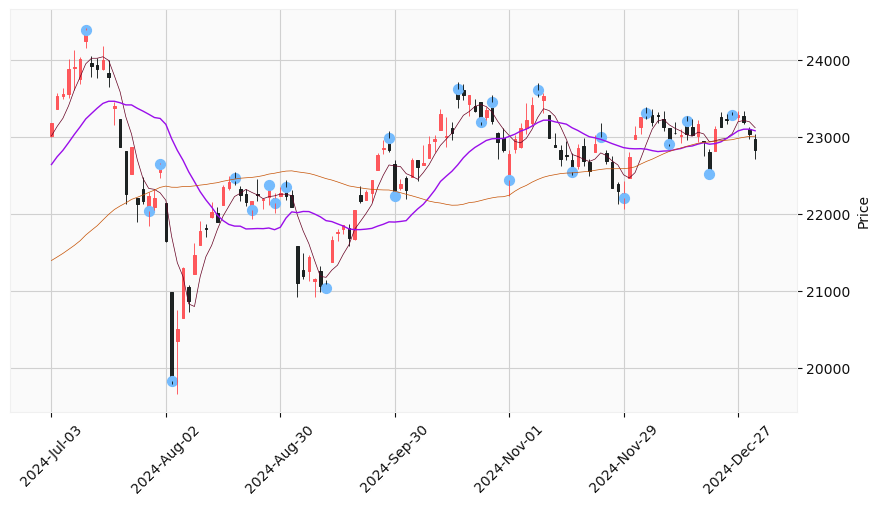

In [4]:
# 偵測轉折點
_,_,max_min = DetectTurningPoints(df_k_line,'open_close')
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 44


,Date,Price,Type
DateIndex,,,
5,2024-07-10,23744.88,LO
6,2024-07-11,24390.03,HI
8,2024-07-15,23879.36,LO
9,2024-07-16,23997.25,HI
13,2024-07-22,22256.99,LO
14,2024-07-23,22871.84,HI
15,2024-07-26,22119.21,LO
16,2024-07-29,22321.37,HI
17,2024-07-30,22040.04,LO


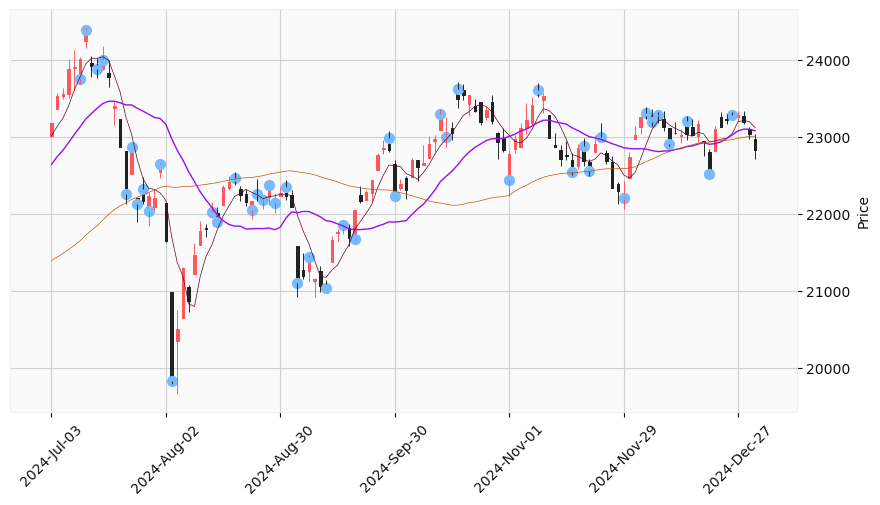

In [5]:
# 偵測轉折點
_,_,max_min = DetectTurningPoints(df_k_line,'open_close',interval=0)
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 3 ， 最小化過濾器的距離參數 ＝ 6 
轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
6,2024-07-11,24390.03,HI
21,2024-08-05,19830.88,LO
32,2024-08-20,22464.07,HI
48,2024-09-11,21031.00,LO
71,2024-10-18,23620.57,HI
80,2024-11-01,22438.93,LO
85,2024-11-08,23608.11,HI
100,2024-11-29,22202.28,LO
104,2024-12-05,23308.29,HI


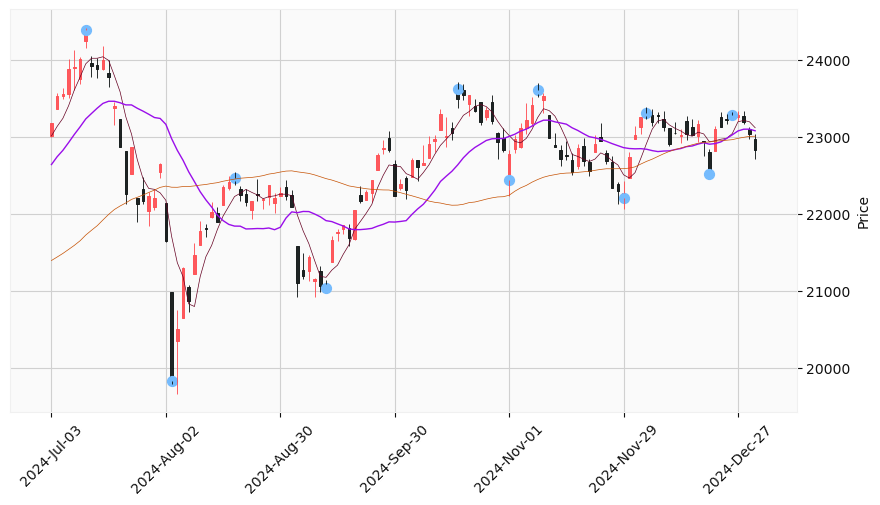

In [6]:
# 偵測轉折點
period = 5
interval = (period//2+1)
_,_,max_min = DetectTurningPoints(df_k_line,'open_close',interval=interval)
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 3 ， 最小化過濾器的距離參數 ＝ 6 
ＤＥＢＵＧ ： 目前索引 ＝ 108 ，波谷間隔之最小索引 ＝ 109
轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
6,2024-07-11,24390.03,HI
21,2024-08-05,19830.88,LO
32,2024-08-20,22429.10,HI
48,2024-09-11,21031.00,LO
72,2024-10-21,23542.53,HI
80,2024-11-01,22780.08,LO
85,2024-11-08,23553.89,HI
100,2024-11-29,22262.50,LO
106,2024-12-09,23273.25,HI


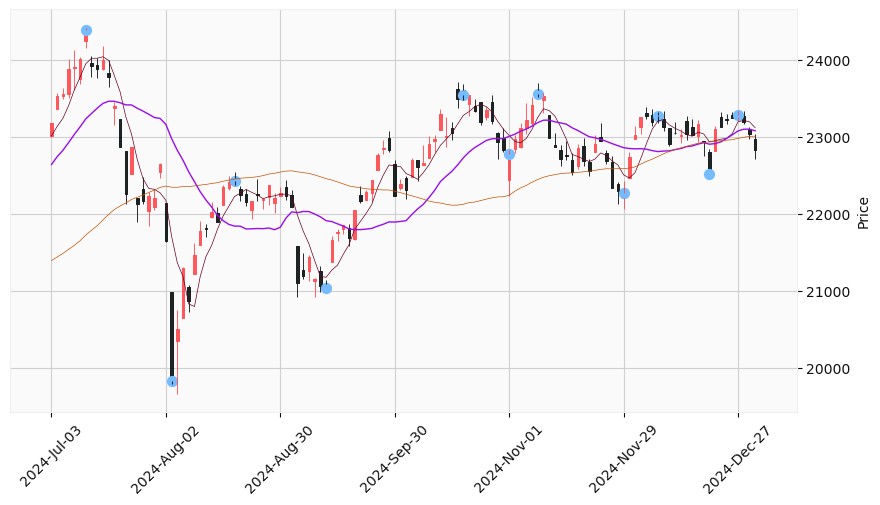

In [7]:
# 偵測轉折點
period = 5
interval = (period//2+1)
_,_,max_min = DetectTurningPoints(df_k_line,'close',interval=interval)
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)